In [25]:
# !pip install pmdarima
# !pip install sktime[all_extras]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error as MAPE
from sklearn.metrics import mean_absolute_error

from sktime.forecasting.arima import AutoARIMA
from sktime.forecasting.compose import (TransformedTargetForecaster, make_reduction)
from sktime.forecasting.model_selection import (ExpandingWindowSplitter, ForecastingGridSearchCV)
from sktime.forecasting.trend import PolynomialTrendForecaster
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
from sktime.transformations.series.detrend import Deseasonalizer, Detrender
from sktime.utils.plotting import plot_series
from pmdarima import AutoARIMA


## Extracting Data and cleaning 
First stage of cleaning involves removing those active in 5-12 mall's times and then furthur removing null entries during maintainence of camera

In [26]:
df = pd.read_csv('parkingLot.csv', parse_dates=['timestamp'])

# Sort by timestamp to aid processing
df.sort_values(by='timestamp', inplace=True)

# Drop null entries logged during maintenance
df_cleaned = df.dropna(subset=['vehicle_no'])
df_cleaned = df_cleaned[(df_cleaned['timestamp'].dt.hour >= 5) & (df_cleaned['timestamp'].dt.hour < 24)]

#Remove those whose vehicle number is blurred
vehicle_pattern = r'^MH[A-Z]{2}\d{4}$'
df_cleaned = df_cleaned[df_cleaned['vehicle_no'].str.match(vehicle_pattern, na=False)]

#Extract entry and exit data 
df_entry = df_cleaned[df_cleaned['camera_id'] == 1]
df_exit = df_cleaned[df_cleaned['camera_id'] == 2]

#Consider only those vehicles that are in both entry and exit
df_entry = df_entry.drop_duplicates(subset='vehicle_no')
df_exit = df_exit.drop_duplicates(subset='vehicle_no')
common_vehicle_numbers = pd.Series(list(set(df_entry['vehicle_no']).intersection(set(df_exit['vehicle_no']))))
df_entry = df_entry[df_entry['vehicle_no'].isin(common_vehicle_numbers)]
df_exit = df_exit[df_exit['vehicle_no'].isin(common_vehicle_numbers)]

# daily count
daily_count = df_entry.groupby(df_entry['timestamp'].dt.date).size()


## Plotting the raw and cleaned data for comparision

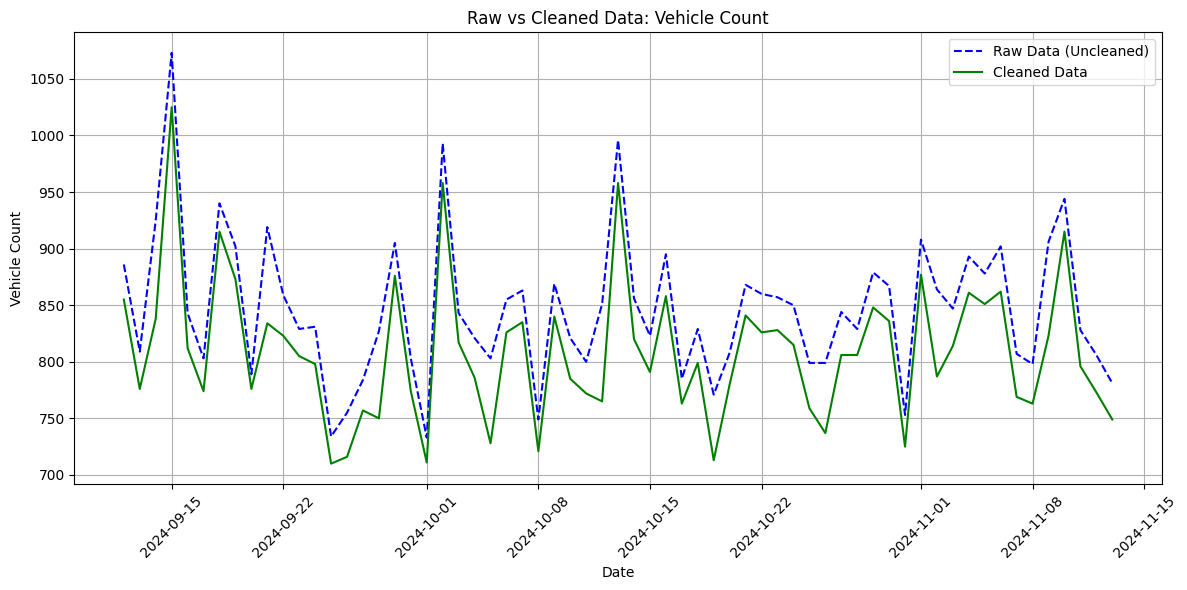

In [27]:
# Calculate daily count and average time for raw (uncleaned) data
df_entry_raw = df[df['camera_id'] == 1]
df_exit_raw = df[df['camera_id'] == 2]

# Raw daily vehicle count
daily_count_raw = df_entry_raw.groupby(df_entry_raw['timestamp'].dt.date).size()

# Plot: Data Before and After Cleaning for Vehicle Count
plt.figure(figsize=(12, 6))
plt.plot(daily_count_raw, label='Raw Data (Uncleaned)', color='blue', linestyle='--')
plt.plot(daily_count, label='Cleaned Data', color='green')
plt.title('Raw vs Cleaned Data: Vehicle Count')
plt.xlabel('Date')
plt.ylabel('Vehicle Count')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


## Splitting into training and testing data

In [28]:
#test data for last 7 days and rest train
train_size = int(len(daily_count)-7)
train_count, test_count = daily_count[:train_size], daily_count[train_size:]

## Plot for training , testing and forcasted data and finding MASE, MAPE

In [29]:
def plot_forecast(series_train, series_test, forecast,benchmark, forecast_int=None):

    mae_actual = mean_absolute_error(series_test, forecast)
    mae_naive=np.mean(np.abs(np.diff(benchmark)))
    MASE=mae_actual/mae_naive
    mape = MAPE(series_test, forecast)

    plt.figure(figsize=(12, 6))
    plt.title(f"MASE: {MASE:.2f}, MAPE: {mape*100:.3f}%, MAE: {mae_actual:.2f}", size=18)
    series_train.plot(label="train", color="b")
    series_test.plot(label="test", color="g")
    forecast.index = series_test.index
    forecast.plot(label="forecast", color="r",linestyle='--')
    if forecast_int is not None:
        plt.fill_between(
            series_test.index,
            forecast_int["lower"],
            forecast_int["upper"],
            alpha=0.2,
            color="dimgray",
        )
    plt.legend(prop={"size": 16})
    plt.show()

    return MASE, mape*100

## Using ARIMA model for forcasting the next 7 days vechicle count and average spent time

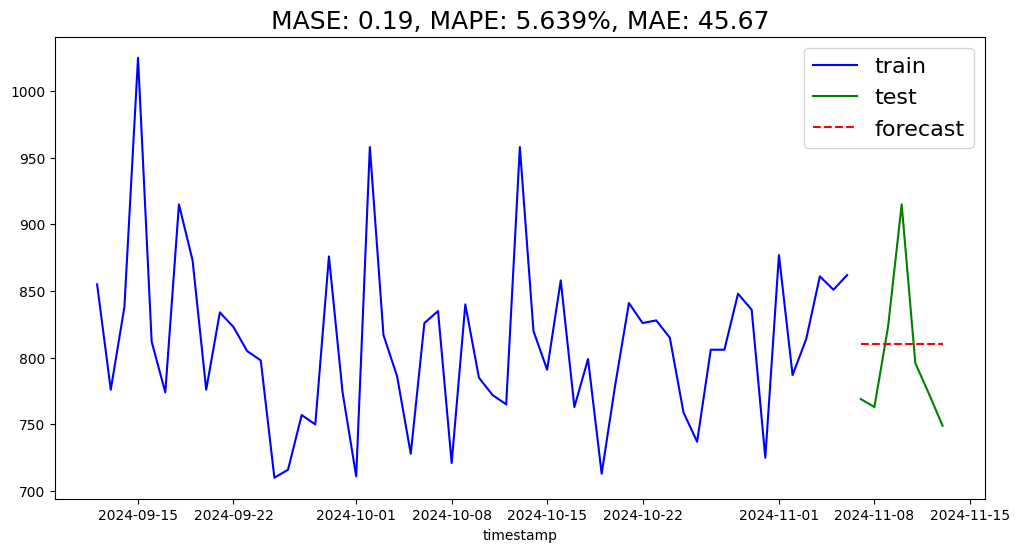

In [30]:
import warnings
warnings.filterwarnings("ignore")
forecaster = AutoARIMA( start_p=1, start_q=1, max_p=10, max_q=10, m=7, seasonal=False,suppress_warnings=True, stepwise=True)
forecaster.fit(train_count)
n_periods = 7
forecast_count = forecaster.predict(n_periods=n_periods)

# Optionally get confidence intervals if needed
forecast_count_int = forecaster.predict(n_periods=n_periods, return_conf_int=True)[1]
count_arima_mae, count_arima_mape = plot_forecast(
    train_count, test_count, forecast_count, forecast_count_int
)